# Bayesian VAR with Pandemic Dummies

This tutorial extends `tutorial_bvar.ipynb` with the **full sample including COVID-19** for a four-variable Peruvian system, and shows how to control for the 2020Q1–2021Q2 extreme observations using time dummies.

**Variables** (quarterly, in Cholesky ordering most-exogenous first):

- `tot`   — Terms of trade, YoY growth (%)
- `conf` — Business confidence (3-month economy expectations index)
- `inv`   — Real private investment, YoY growth (%)
- `int`   — Interbank rate, level (% p.a.)

**Research question.** What is the impact of (i) terms-of-trade shocks and (ii) business-confidence shocks on private investment?

**Why dummies.** Six pandemic quarters (2020Q1–2021Q2) contain extreme values that, if left unmodelled, get baked into the estimated dynamics of every equation. Pandemic dummies absorb those outliers so that the impulse responses reflect *normal-time* propagation rather than a hybrid of normal and crisis dynamics.

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('../datasets/Peru_Data.csv', index_col=0, parse_dates=True)
df.index.name = 'date'
df.rename(columns={"g_tdi": "tot", "exp3m": "conf", "g_invpriv": "inv"}, inplace=True)
df = df[['tot', 'conf', 'inv', 'int']]
print(f"Sample: {df.index.min().date()} → {df.index.max().date()}  ({len(df)} quarters)")
df.head()

Sample: 2002-06-01 → 2025-12-01  (95 quarters)


,tot,conf,inv,int
date,,,,
2002-06-01,9.142557,56.858778,-0.621269,2.533333
2002-09-01,6.959633,57.006907,-2.667409,3.746789
2002-12-01,6.454193,65.792601,6.614539,4.113330
2003-03-01,0.598476,65.962466,8.915503,3.790000
2003-06-01,-3.132779,57.784782,6.115858,3.786667


## 1. Visualising the pandemic shock

The 2020Q2 lockdown collapse and the 2021Q2 base-effect rebound are visible in every series — they are exactly the kind of observations that pollute VAR estimates if left unmodelled.

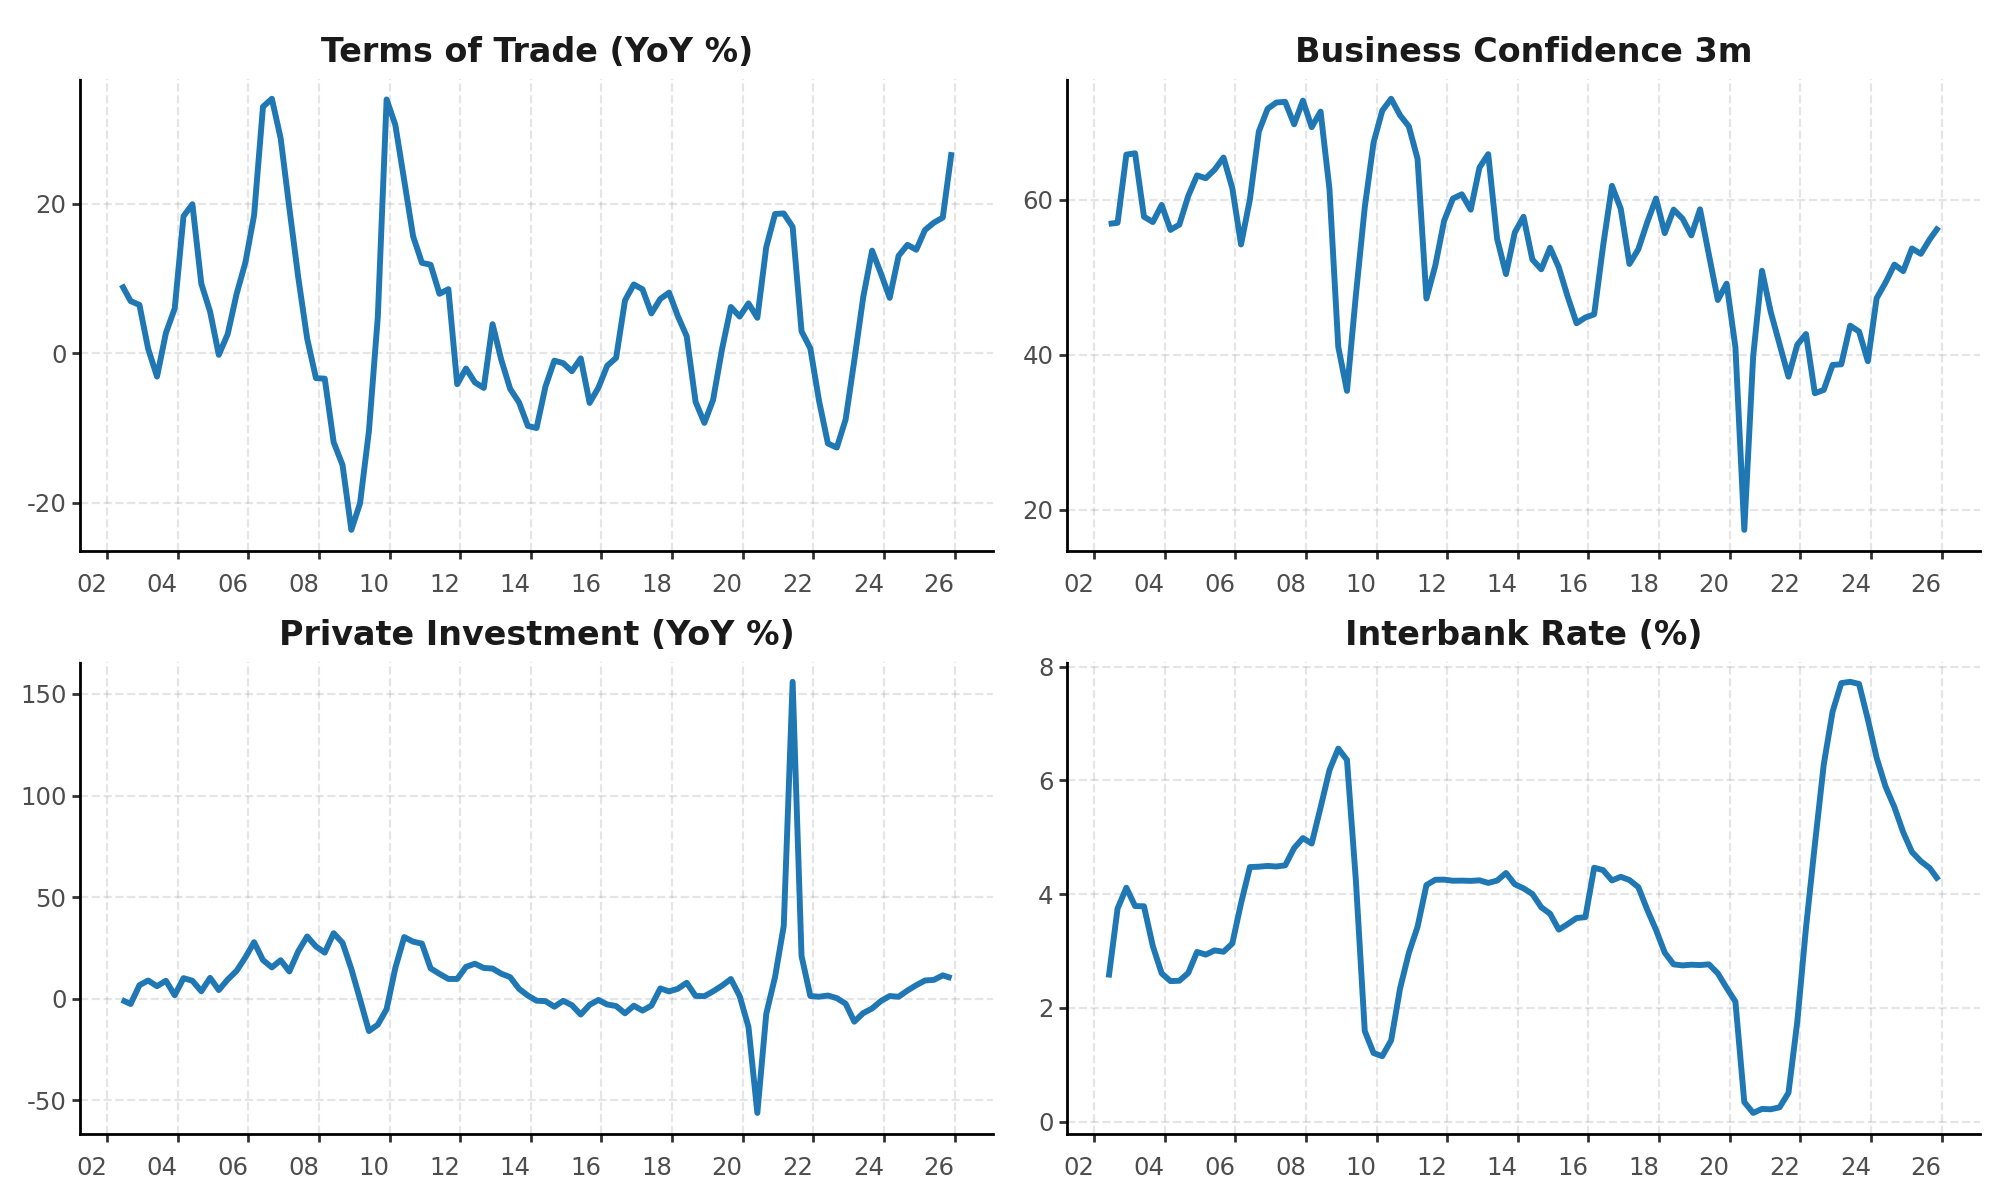

In [2]:
from MacroPy import generate_series_plot

titles = ['Terms of Trade (YoY %)', 'Business Confidence 3m',
          'Private Investment (YoY %)', 'Interbank Rate (%)']
generate_series_plot(df, series_titles=titles, n_breaks=12)

## 2. Constructing the pandemic dummies

We build six one-hot dummies, one per pandemic quarter from 2020Q1 to 2021Q2. Each is a column equal to 1 at its quarter and 0 elsewhere. This is the most flexible specification: every equation gets a distinct, free parameter for every pandemic quarter.

In [3]:
pandemic_quarters = pd.date_range('2020-03-01', '2021-06-01', freq='QS-MAR')
pandemic_quarters = [d.to_period('Q').to_timestamp(how='start') + pd.DateOffset(months=2)
                     for d in pandemic_quarters]

dummies = pd.DataFrame(0.0, index=df.index,
                       columns=[f'd_{d.year}Q{((d.month-1)//3)+1}' for d in pandemic_quarters])
for d, col in zip(pandemic_quarters, dummies.columns):
    dummies.loc[d, col] = 1.0

dummies.loc['2019-12-01':'2021-09-01']

,d_2020Q1,d_2020Q2,d_2020Q3,d_2020Q4,d_2021Q1,d_2021Q2
date,,,,,,
2019-12-01,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-01,1.0,0.0,0.0,0.0,0.0,0.0
2020-06-01,0.0,1.0,0.0,0.0,0.0,0.0
2020-09-01,0.0,0.0,1.0,0.0,0.0,0.0
2020-12-01,0.0,0.0,0.0,1.0,0.0,0.0
2021-03-01,0.0,0.0,0.0,0.0,1.0,0.0
2021-06-01,0.0,0.0,0.0,0.0,0.0,1.0
2021-09-01,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Baseline: BVAR without dummies

First, the model that *ignores* the pandemic. We use 2 lags, a Normal-Wishart prior, and Cholesky identification with `tot → conf → inv → int`.

In [4]:
from MacroPy import BayesianVAR

prior_params = {'mn_mean': 0.5, 
                'lamda1': 0.8, 
                'lamda2': 1.0, 
                'lamda3': 2.0, 
                'lamda4': 1e5}

block_exog = np.array([
                [0, 1, 1, 1],  # Variable 2, 3 and 4 does NOT affect equation 1
                [0, 0, 0, 0],  # No restriction in equation 2
                [0, 0, 0, 0],  # No restriction in equation 3
                [0, 0, 0, 0],  # No restriction in equation 4
            ])

bvar_base = BayesianVAR(df, lags=2, prior_type=2, prior_params=prior_params,
                        b_exo=block_exog, post_draws=5000, burnin=0.5)
bvar_base.model_summary()


**MacroPy: A Toolbox for Bayesian Macroeconometric Analysis in Python**
Developed by [Renato Vassallo](https://www.linkedin.com/in/renatovassallo) - Institute for Economic Analysis (IAE-CSIC)
Version 0.1.7

---

**Model Specifications**  
- **Model Type**: Bayesian VAR
- **Endogenous Variables**: tot, conf, inv, int
- **Exogenous Variables**: Constant
- **Number of Lags**: 2
- **Sample Period**: 2002-12-01 to 2025-12-01 (93 observations)
- **Total Parameters Estimated**: 36

---

**Bayesian Estimation Settings**
- **Posterior Simulation**: Gibbs Sampling
- **Prior Type**: Normal-Wishart
- **Total Draws**: 5000
- **Burn-in**: 2500 (50%)

---

**Forecast & IRF Details**
- **Impulse Response Horizon**: 20
- **Forecast Horizon**: 12
- **IRF Computation**: 1 Standard Deviation

---

**Model Equations**

$$
\begin{align*}
tot_{t} &= b_{1,1}^{1} tot_{t-1} + b_{1,2}^{1} conf_{t-1} + b_{1,3}^{1} inv_{t-1} + b_{1,4}^{1} int_{t-1} + b_{1,1}^{2} tot_{t-2} + b_{1,2}^{2} conf_{t-2} + b_{1,3}^{2} inv_{t-2} + b_{1,4}^{2} int_{t-2} + c_{1} + e_{t}^{tot} \\
conf_{t} &= b_{2,1}^{1} tot_{t-1} + b_{2,2}^{1} conf_{t-1} + b_{2,3}^{1} inv_{t-1} + b_{2,4}^{1} int_{t-1} + b_{2,1}^{2} tot_{t-2} + b_{2,2}^{2} conf_{t-2} + b_{2,3}^{2} inv_{t-2} + b_{2,4}^{2} int_{t-2} + c_{2} + e_{t}^{conf} \\
inv_{t} &= b_{3,1}^{1} tot_{t-1} + b_{3,2}^{1} conf_{t-1} + b_{3,3}^{1} inv_{t-1} + b_{3,4}^{1} int_{t-1} + b_{3,1}^{2} tot_{t-2} + b_{3,2}^{2} conf_{t-2} + b_{3,3}^{2} inv_{t-2} + b_{3,4}^{2} int_{t-2} + c_{3} + e_{t}^{inv} \\
int_{t} &= b_{4,1}^{1} tot_{t-1} + b_{4,2}^{1} conf_{t-1} + b_{4,3}^{1} inv_{t-1} + b_{4,4}^{1} int_{t-1} + b_{4,1}^{2} tot_{t-2} + b_{4,2}^{2} conf_{t-2} + b_{4,3}^{2} inv_{t-2} + b_{4,4}^{2} int_{t-2} + c_{4} + e_{t}^{int} \\
\end{align*}
$$


Computing IRFs: 100%|██████████| 2500/2500 [00:00<00:00, 3270.46it/s]


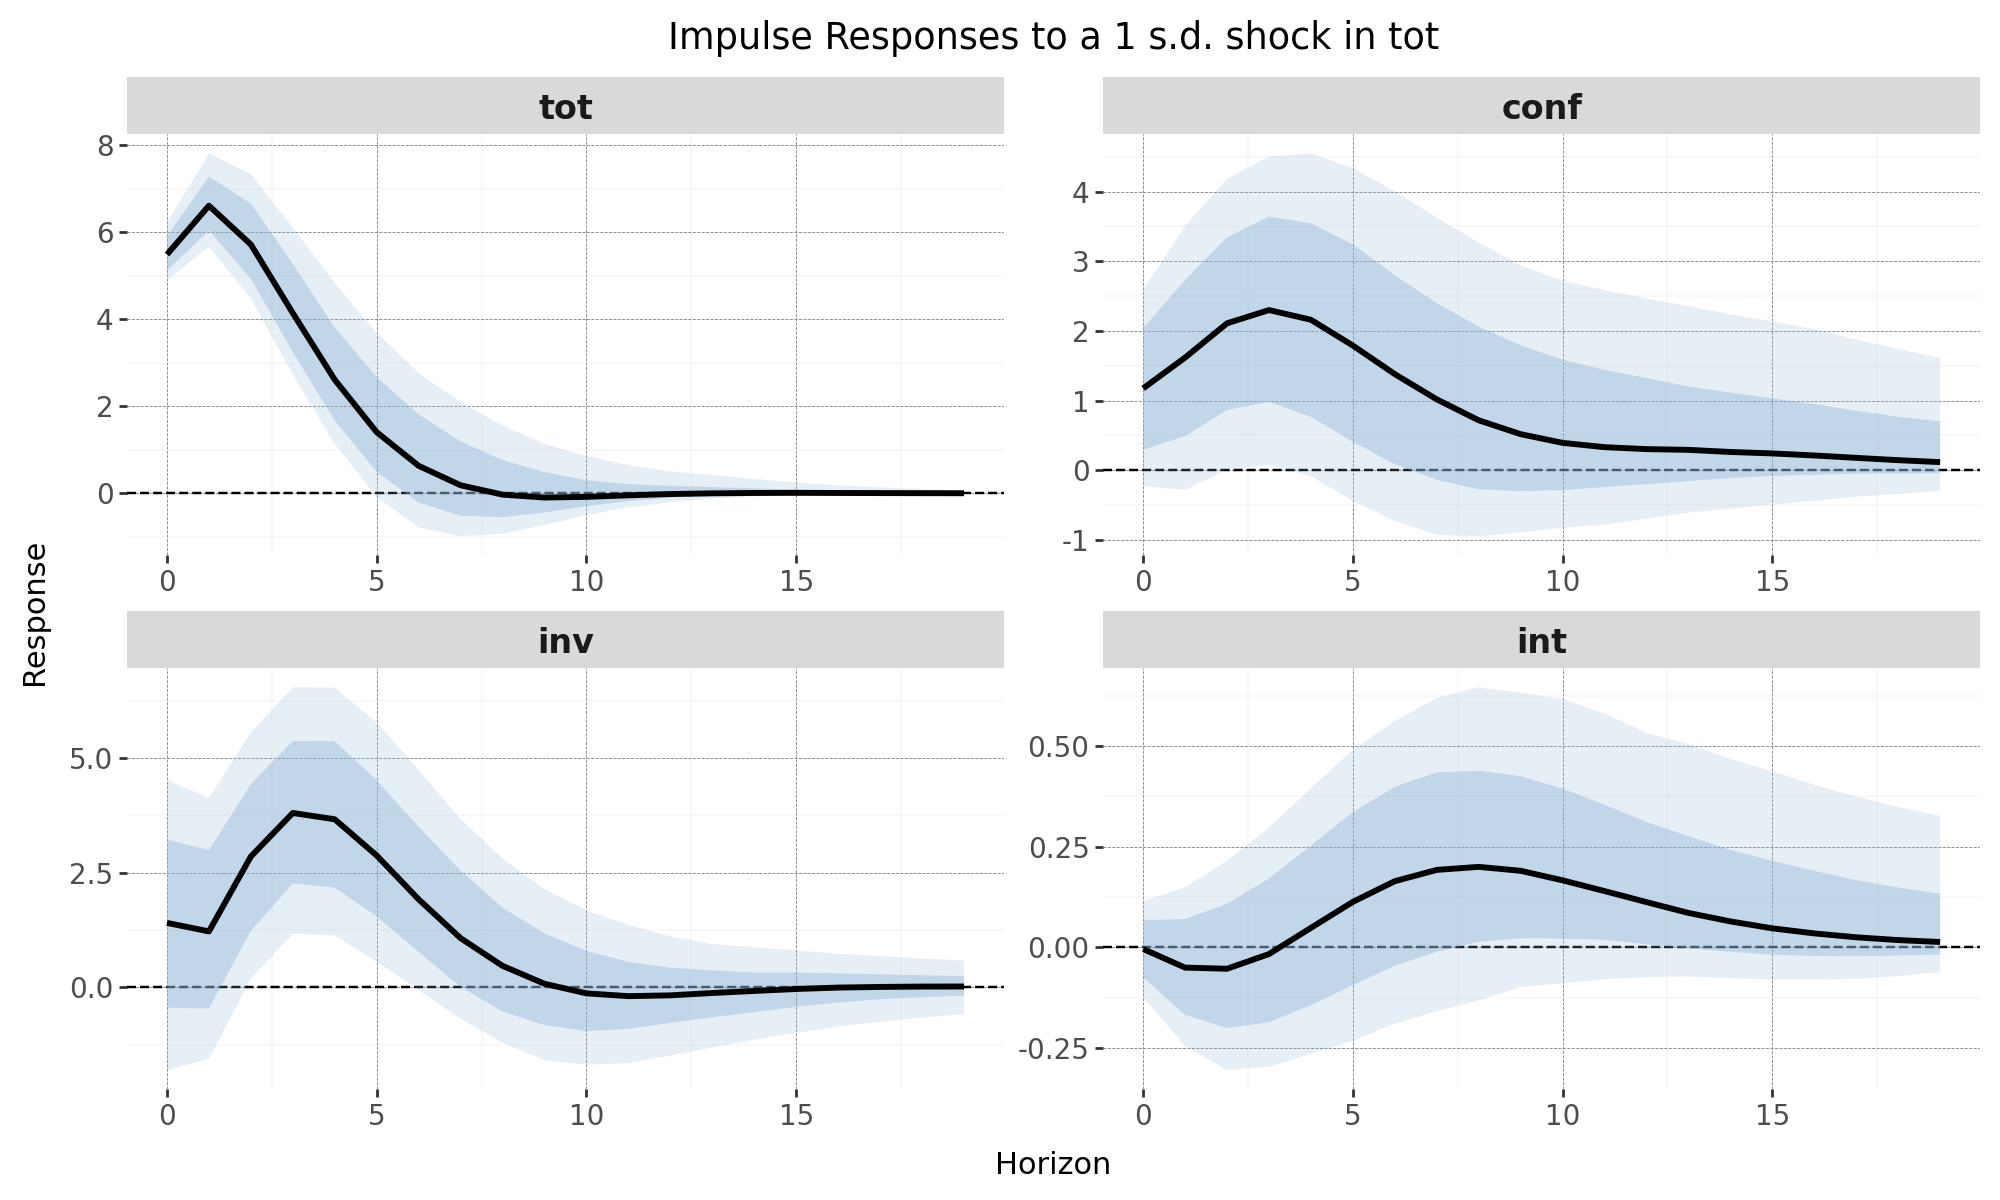

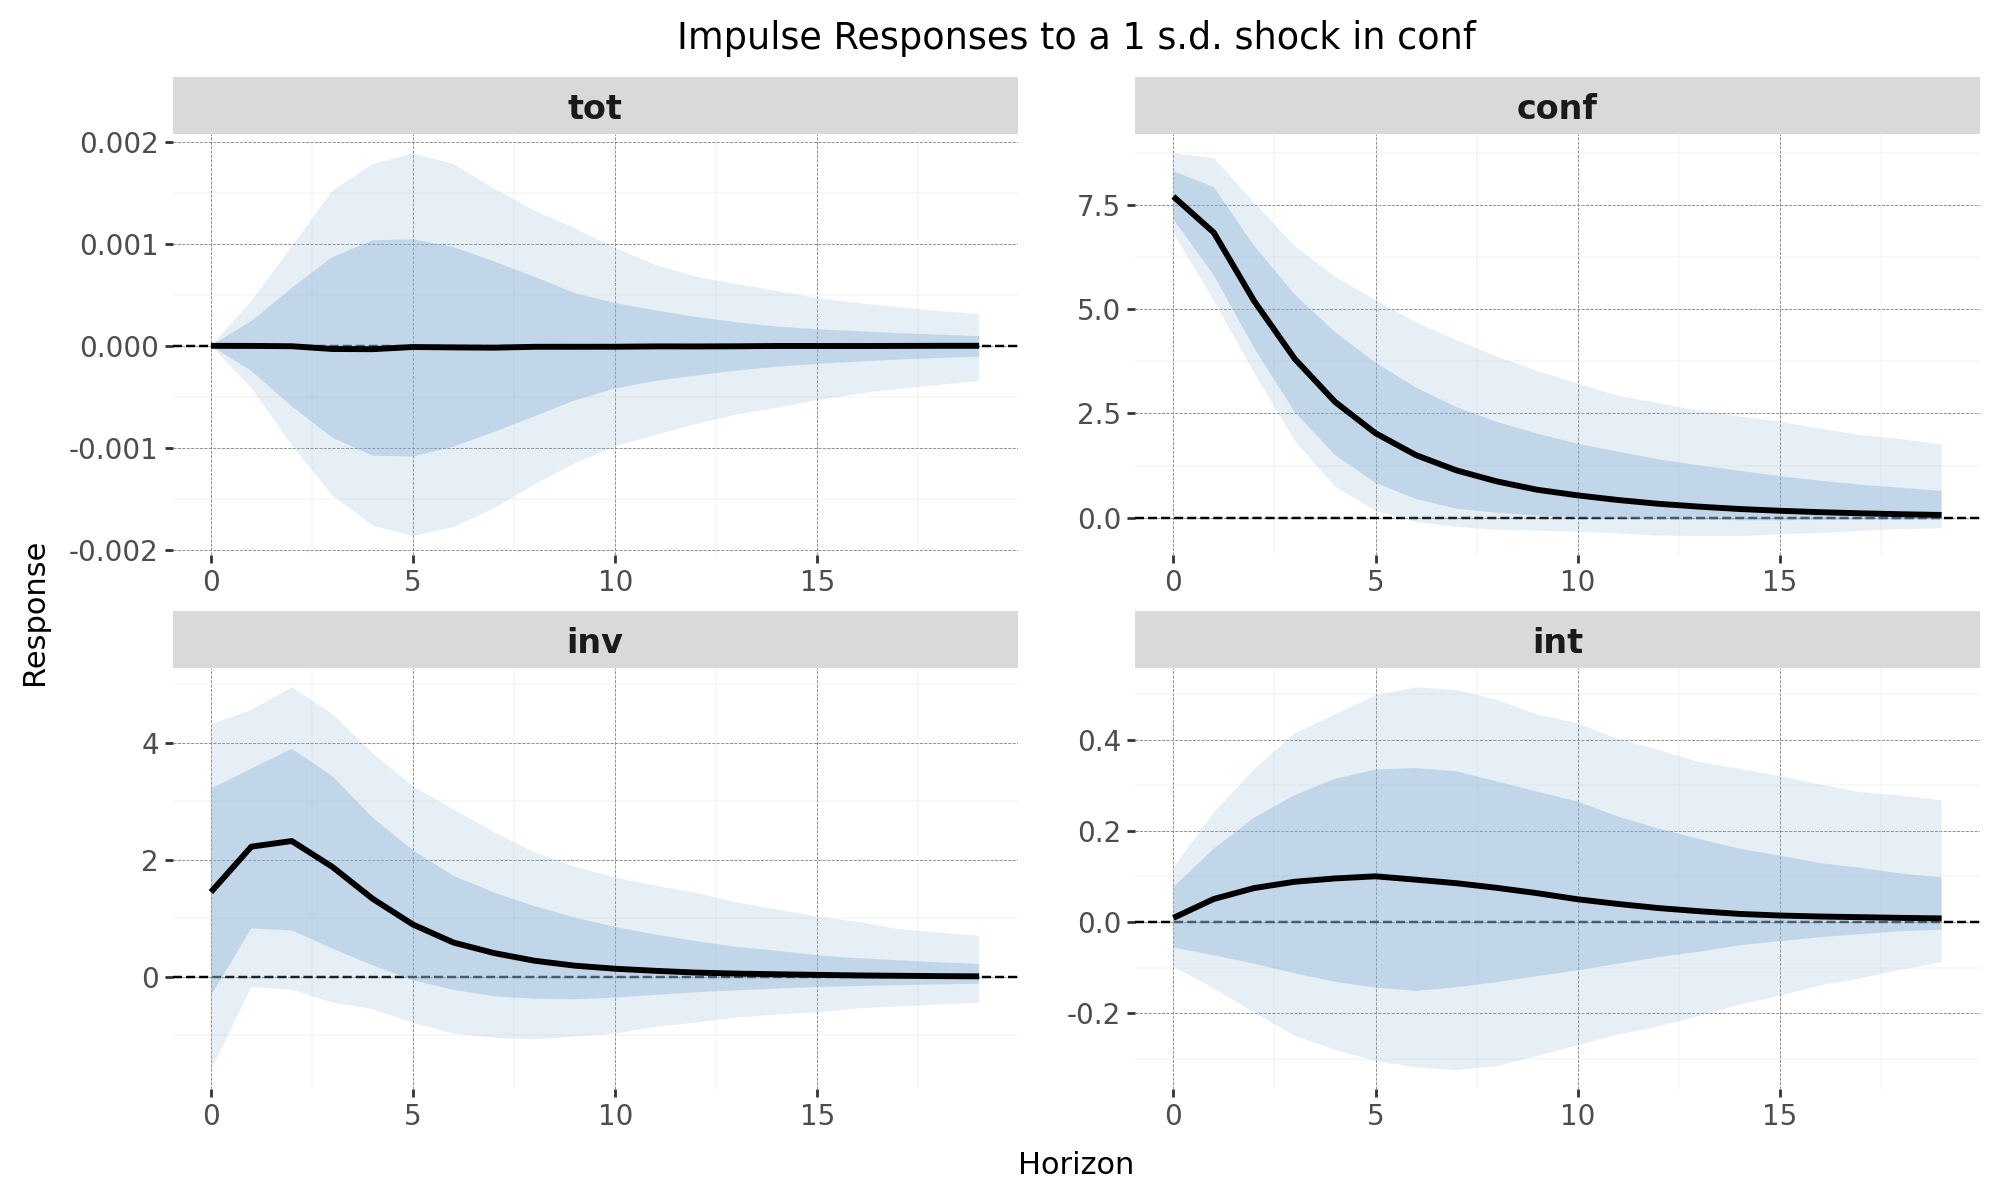

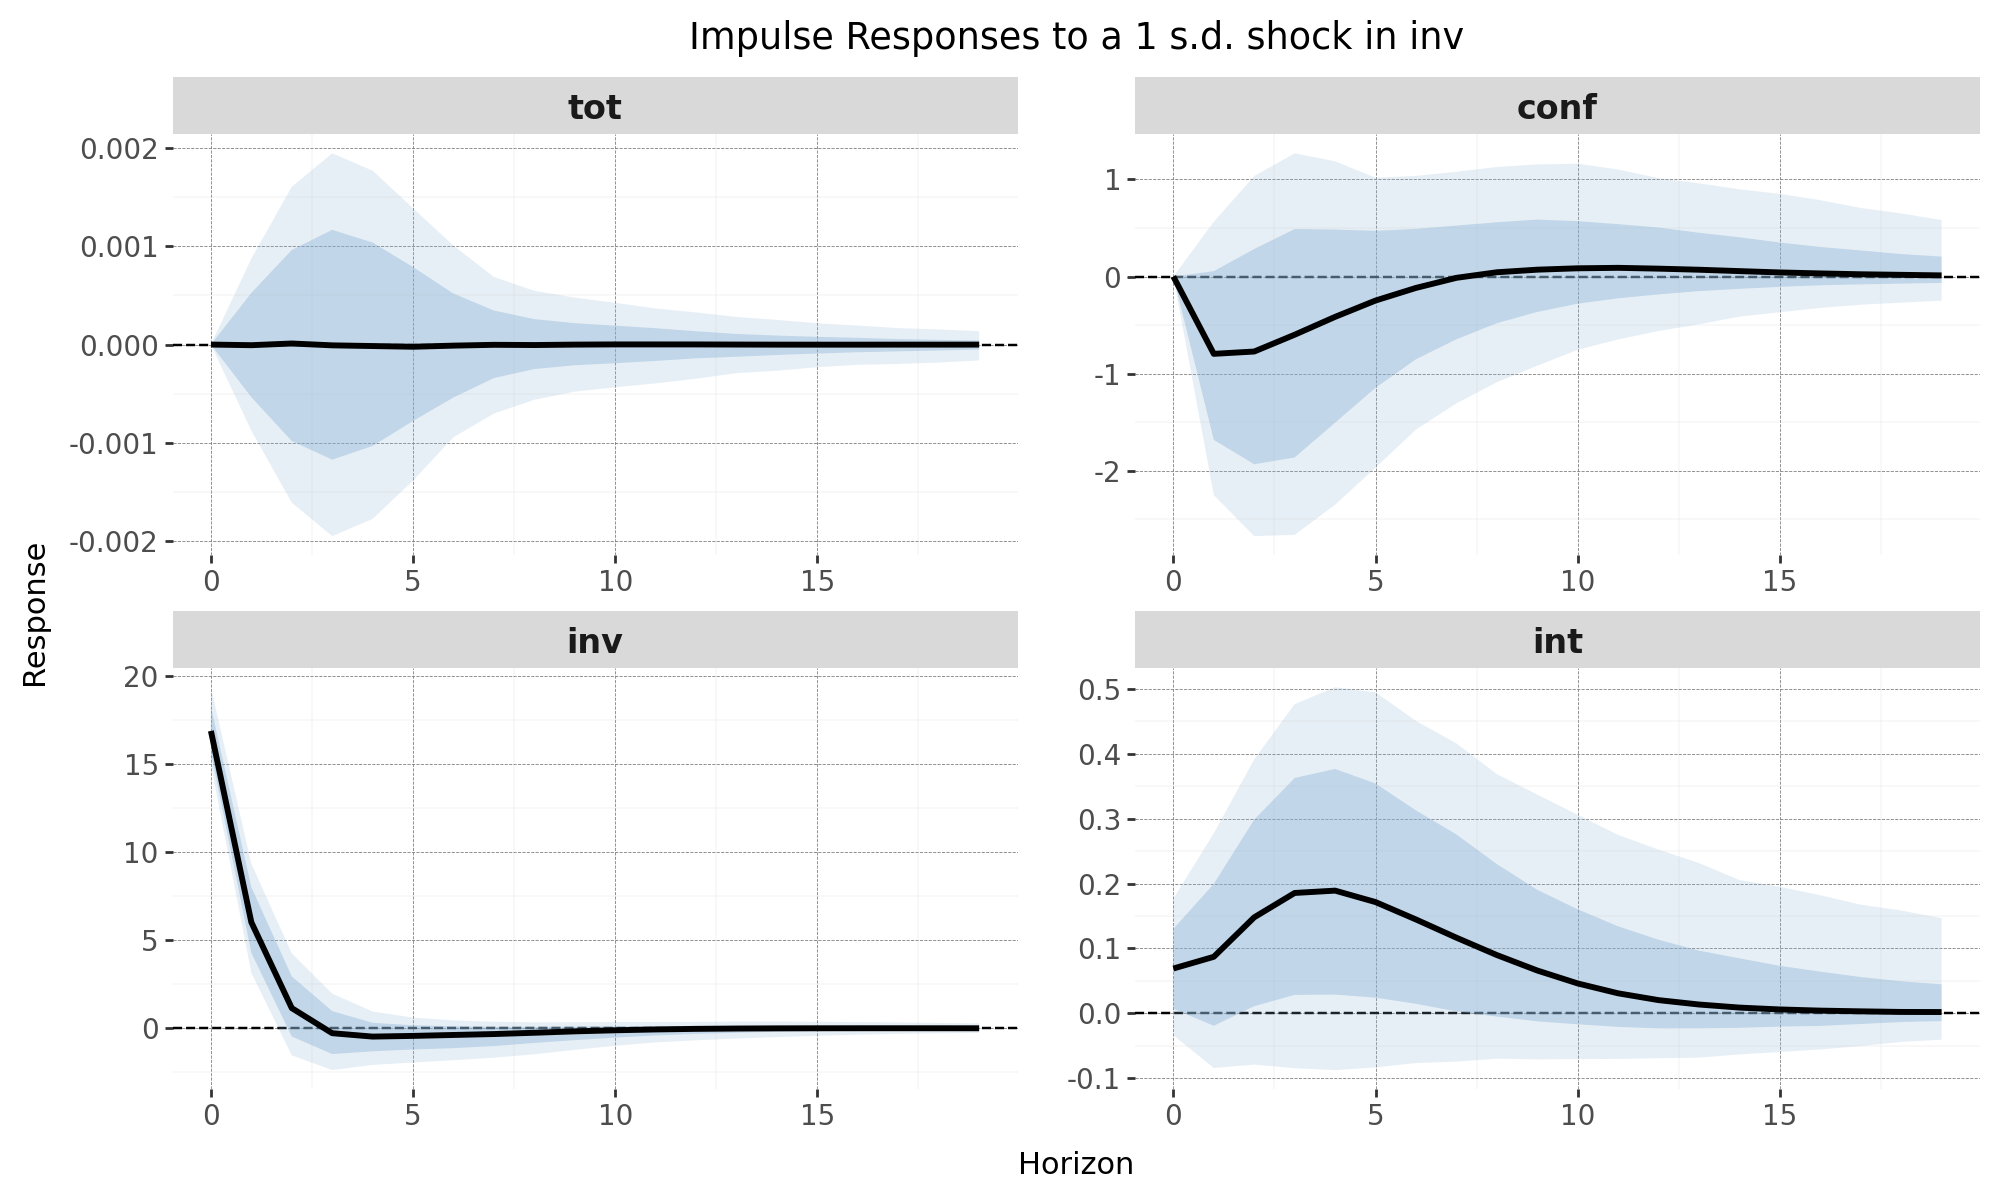

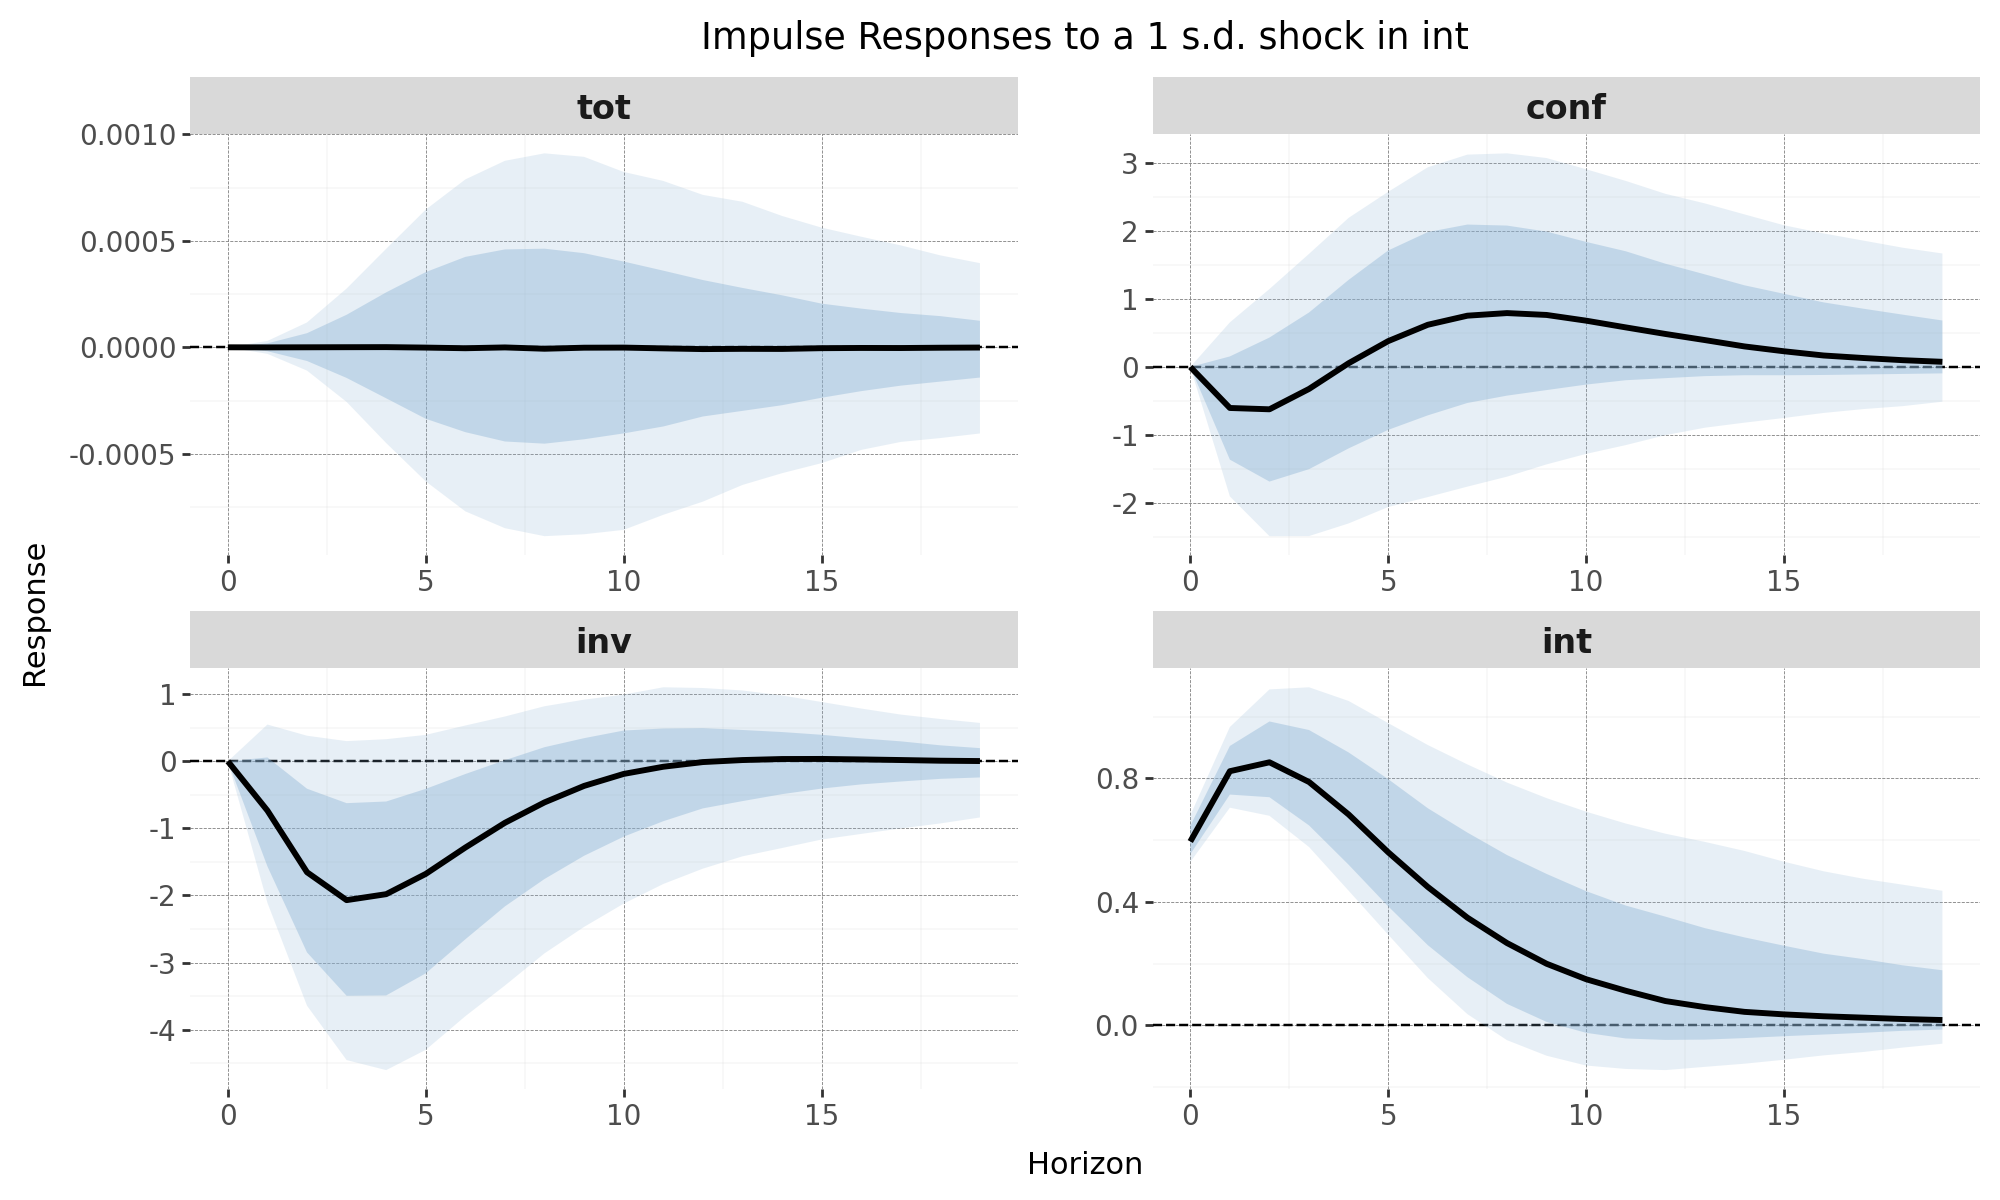

In [5]:
post_base = bvar_base.sample_posterior(plot_coefficients=False)
irfs_base = bvar_base.compute_irfs(plot_irfs=True, cred_interval=[0.68, 0.90])

## 4. With pandemic dummies

Same specification, plus six dummies passed via `exog=`. Each dummy receives a loose Minnesota prior, so the data drives its posterior.

In [6]:
bvar_pd = BayesianVAR(df, lags=2, prior_type=2, prior_params=prior_params,
                      exog=dummies,
                      b_exo=block_exog, post_draws=5000, burnin=0.5)
bvar_pd.model_summary()


**MacroPy: A Toolbox for Bayesian Macroeconometric Analysis in Python**
Developed by [Renato Vassallo](https://www.linkedin.com/in/renatovassallo) - Institute for Economic Analysis (IAE-CSIC)
Version 0.1.7

---

**Model Specifications**  
- **Model Type**: Bayesian VAR
- **Endogenous Variables**: tot, conf, inv, int
- **Exogenous Variables**: Constant, d_2020Q1, d_2020Q2, d_2020Q3, d_2020Q4, d_2021Q1, d_2021Q2
- **Number of Lags**: 2
- **Sample Period**: 2002-12-01 to 2025-12-01 (93 observations)
- **Total Parameters Estimated**: 60

---

**Bayesian Estimation Settings**
- **Posterior Simulation**: Gibbs Sampling
- **Prior Type**: Normal-Wishart
- **Total Draws**: 5000
- **Burn-in**: 2500 (50%)

---

**Forecast & IRF Details**
- **Impulse Response Horizon**: 20
- **Forecast Horizon**: 12
- **IRF Computation**: 1 Standard Deviation

---

**Model Equations**

$$
\begin{align*}
tot_{t} &= b_{1,1}^{1} tot_{t-1} + b_{1,2}^{1} conf_{t-1} + b_{1,3}^{1} inv_{t-1} + b_{1,4}^{1} int_{t-1} + b_{1,1}^{2} tot_{t-2} + b_{1,2}^{2} conf_{t-2} + b_{1,3}^{2} inv_{t-2} + b_{1,4}^{2} int_{t-2} + c_{1} + e_{t}^{tot} \\
conf_{t} &= b_{2,1}^{1} tot_{t-1} + b_{2,2}^{1} conf_{t-1} + b_{2,3}^{1} inv_{t-1} + b_{2,4}^{1} int_{t-1} + b_{2,1}^{2} tot_{t-2} + b_{2,2}^{2} conf_{t-2} + b_{2,3}^{2} inv_{t-2} + b_{2,4}^{2} int_{t-2} + c_{2} + e_{t}^{conf} \\
inv_{t} &= b_{3,1}^{1} tot_{t-1} + b_{3,2}^{1} conf_{t-1} + b_{3,3}^{1} inv_{t-1} + b_{3,4}^{1} int_{t-1} + b_{3,1}^{2} tot_{t-2} + b_{3,2}^{2} conf_{t-2} + b_{3,3}^{2} inv_{t-2} + b_{3,4}^{2} int_{t-2} + c_{3} + e_{t}^{inv} \\
int_{t} &= b_{4,1}^{1} tot_{t-1} + b_{4,2}^{1} conf_{t-1} + b_{4,3}^{1} inv_{t-1} + b_{4,4}^{1} int_{t-1} + b_{4,1}^{2} tot_{t-2} + b_{4,2}^{2} conf_{t-2} + b_{4,3}^{2} inv_{t-2} + b_{4,4}^{2} int_{t-2} + c_{4} + e_{t}^{int} \\
\end{align*}
$$


In [7]:
post_pd = bvar_pd.sample_posterior(plot_coefficients=False)

Sampling Posterior: 100%|██████████| 5000/5000 [00:05<00:00, 860.09it/s] 


### 4.1 Posterior distributions of the pandemic dummies

Each column shows one equation in the system; each row, one pandemic quarter. The histograms reveal which quarters were anomalous in which equation. A dummy whose posterior mass is concentrated away from zero is doing meaningful work — it is absorbing variance that would otherwise distort the lag coefficients.

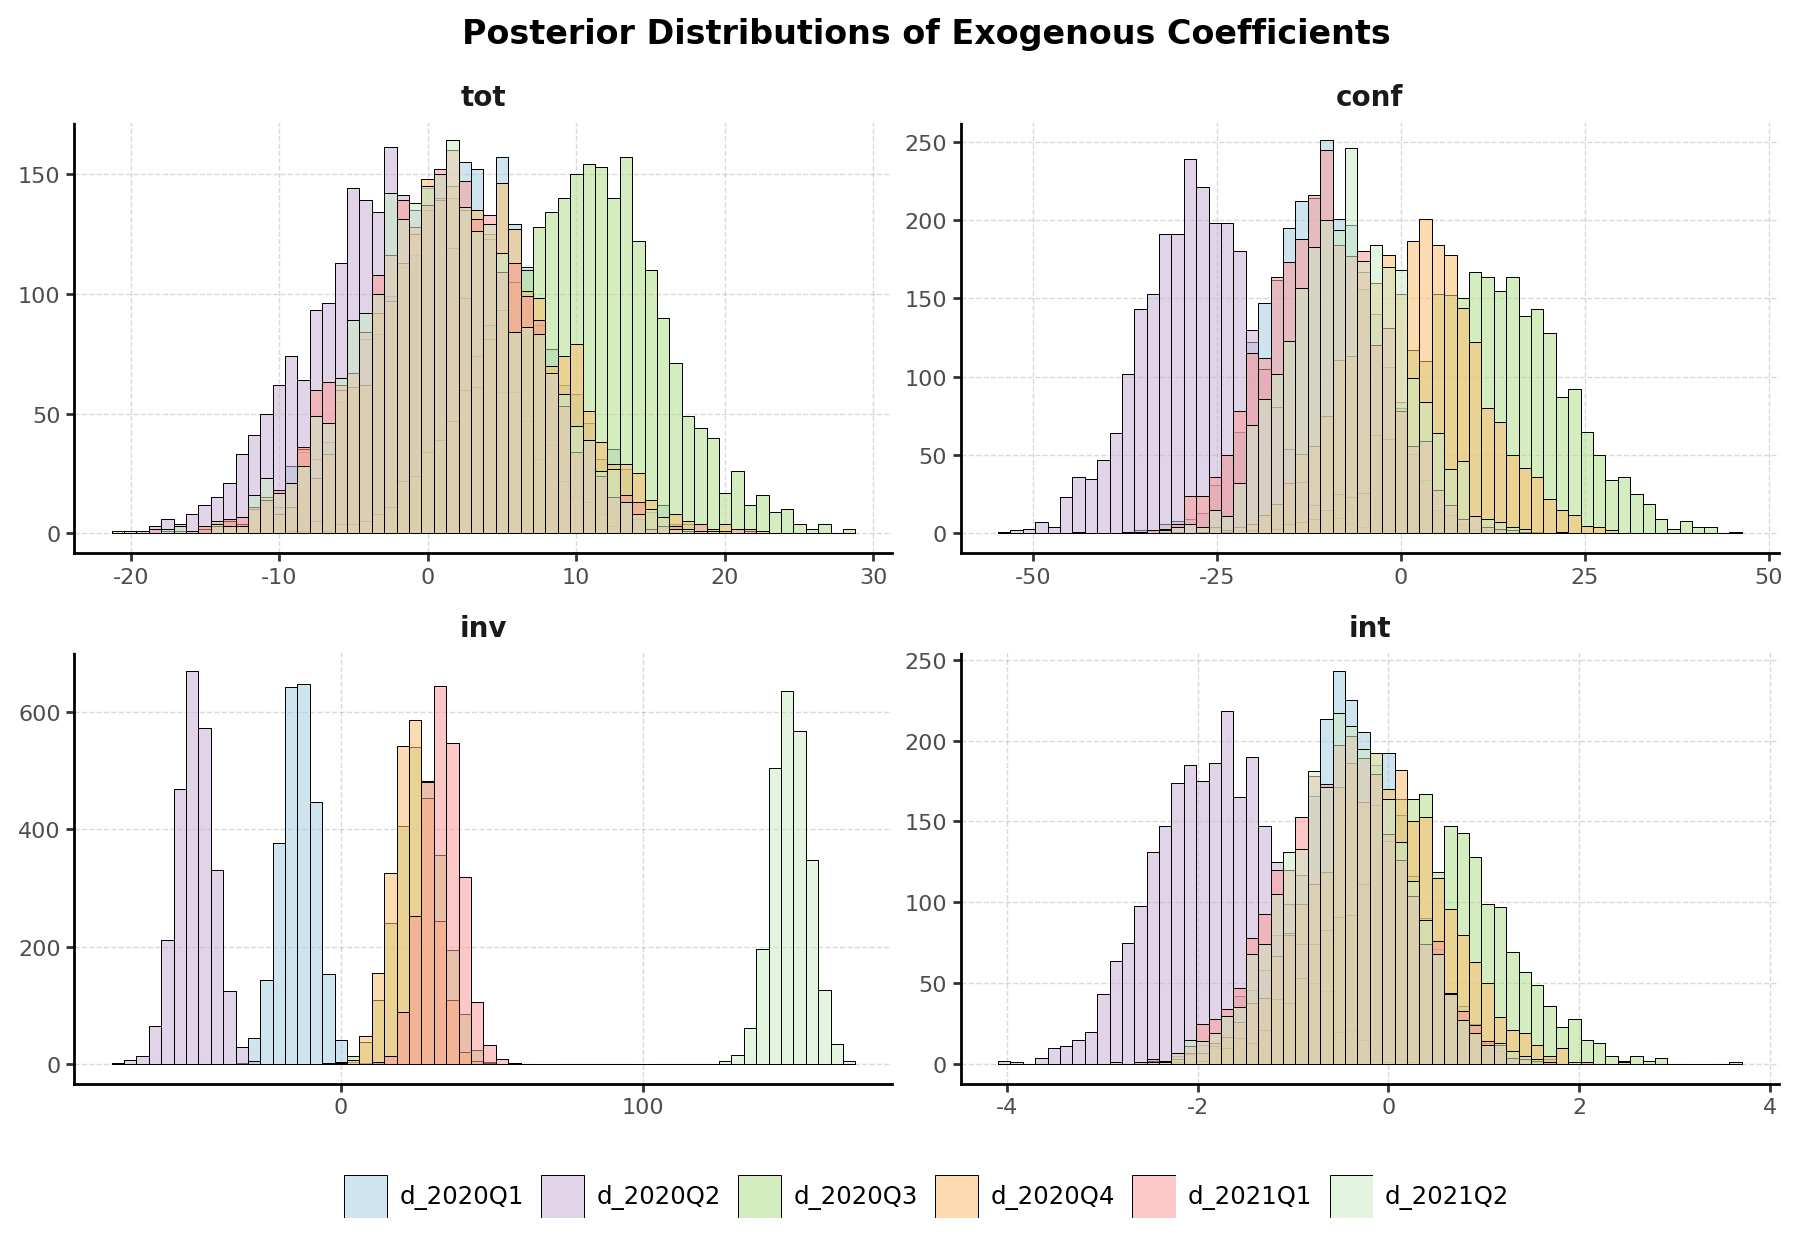

In [8]:
_ = bvar_pd.plot_exog_posteriors(bins=60)

### 4.2 IRFs with pandemic dummies

Computing IRFs: 100%|██████████| 2500/2500 [00:00<00:00, 3226.96it/s]


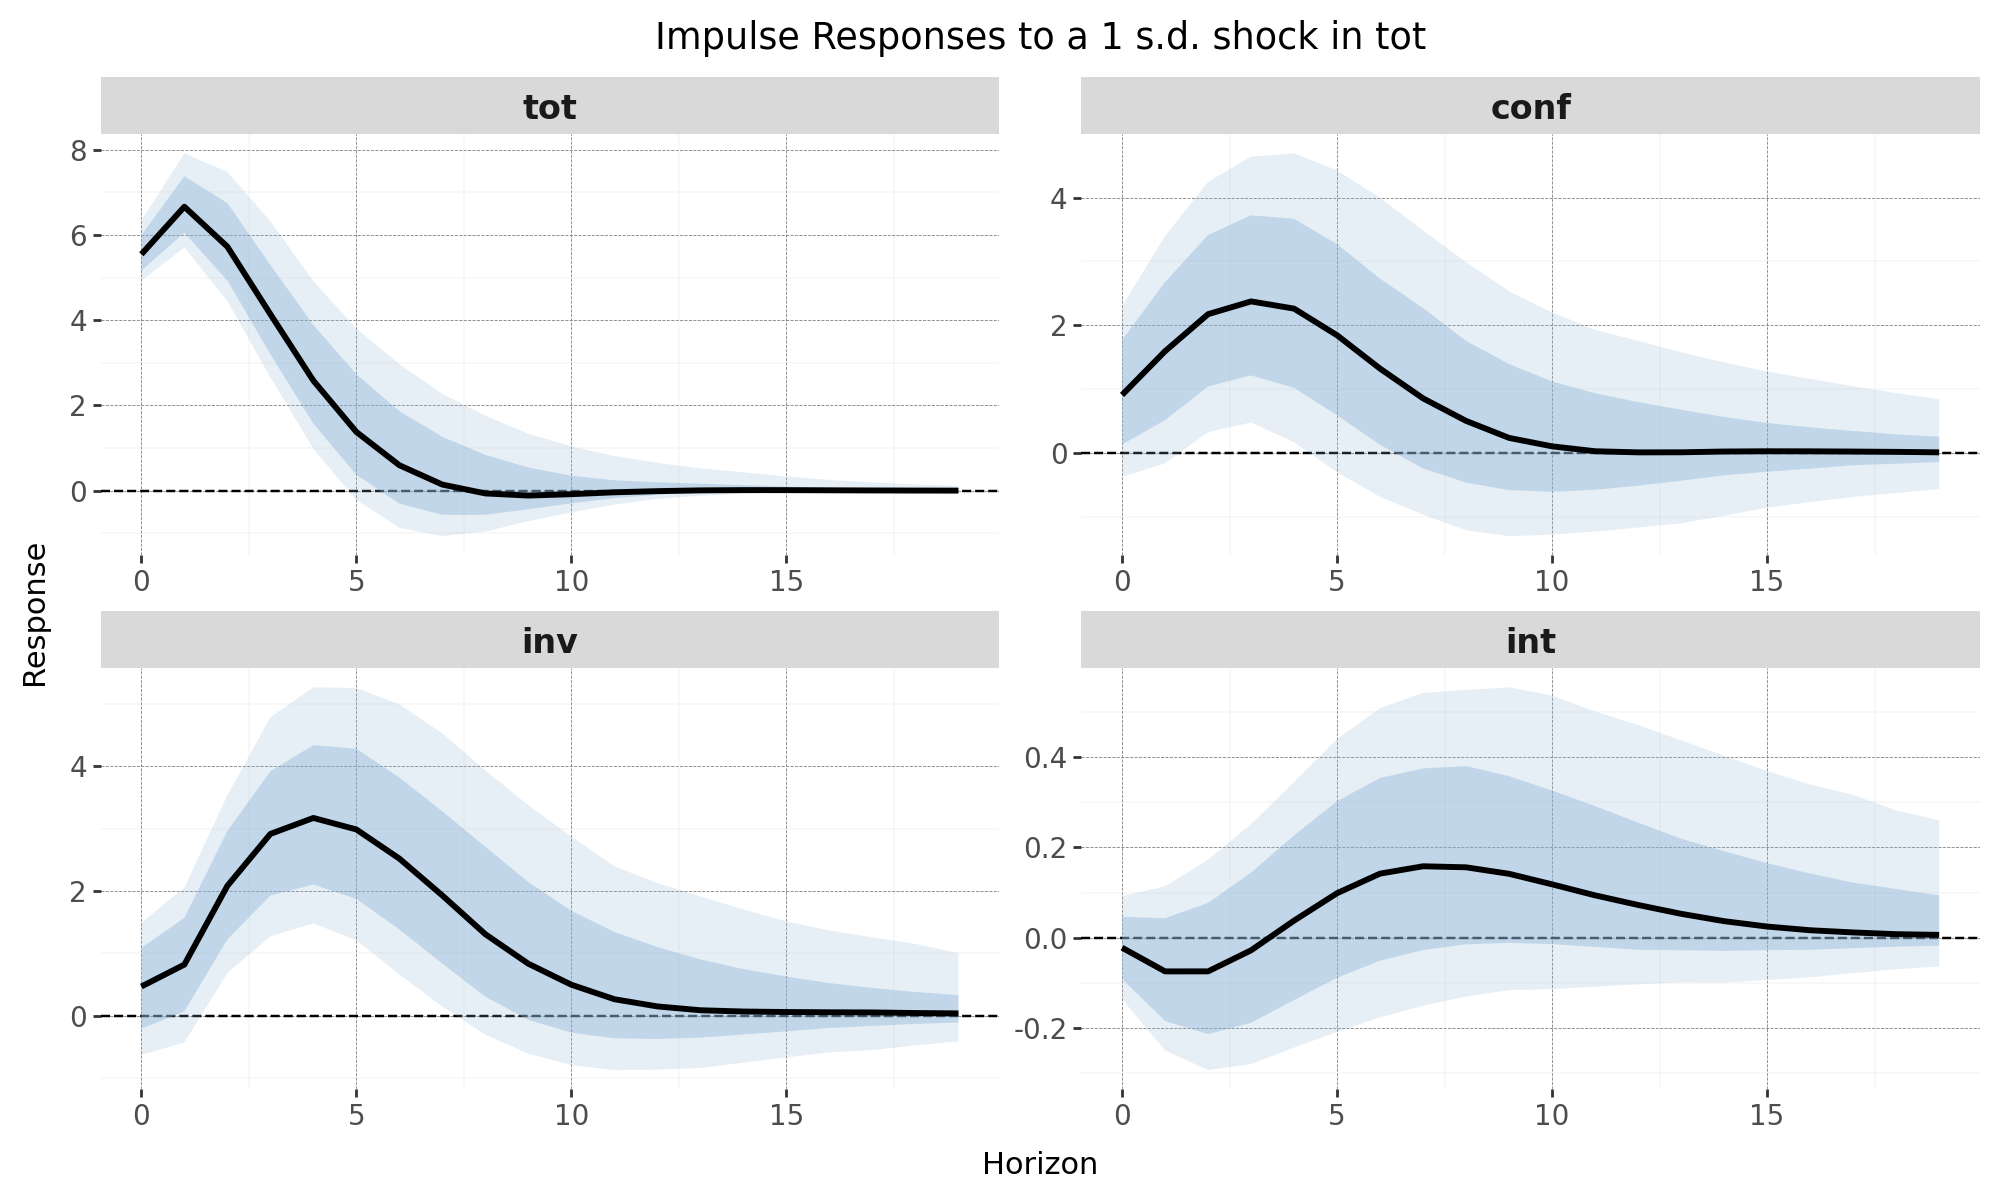

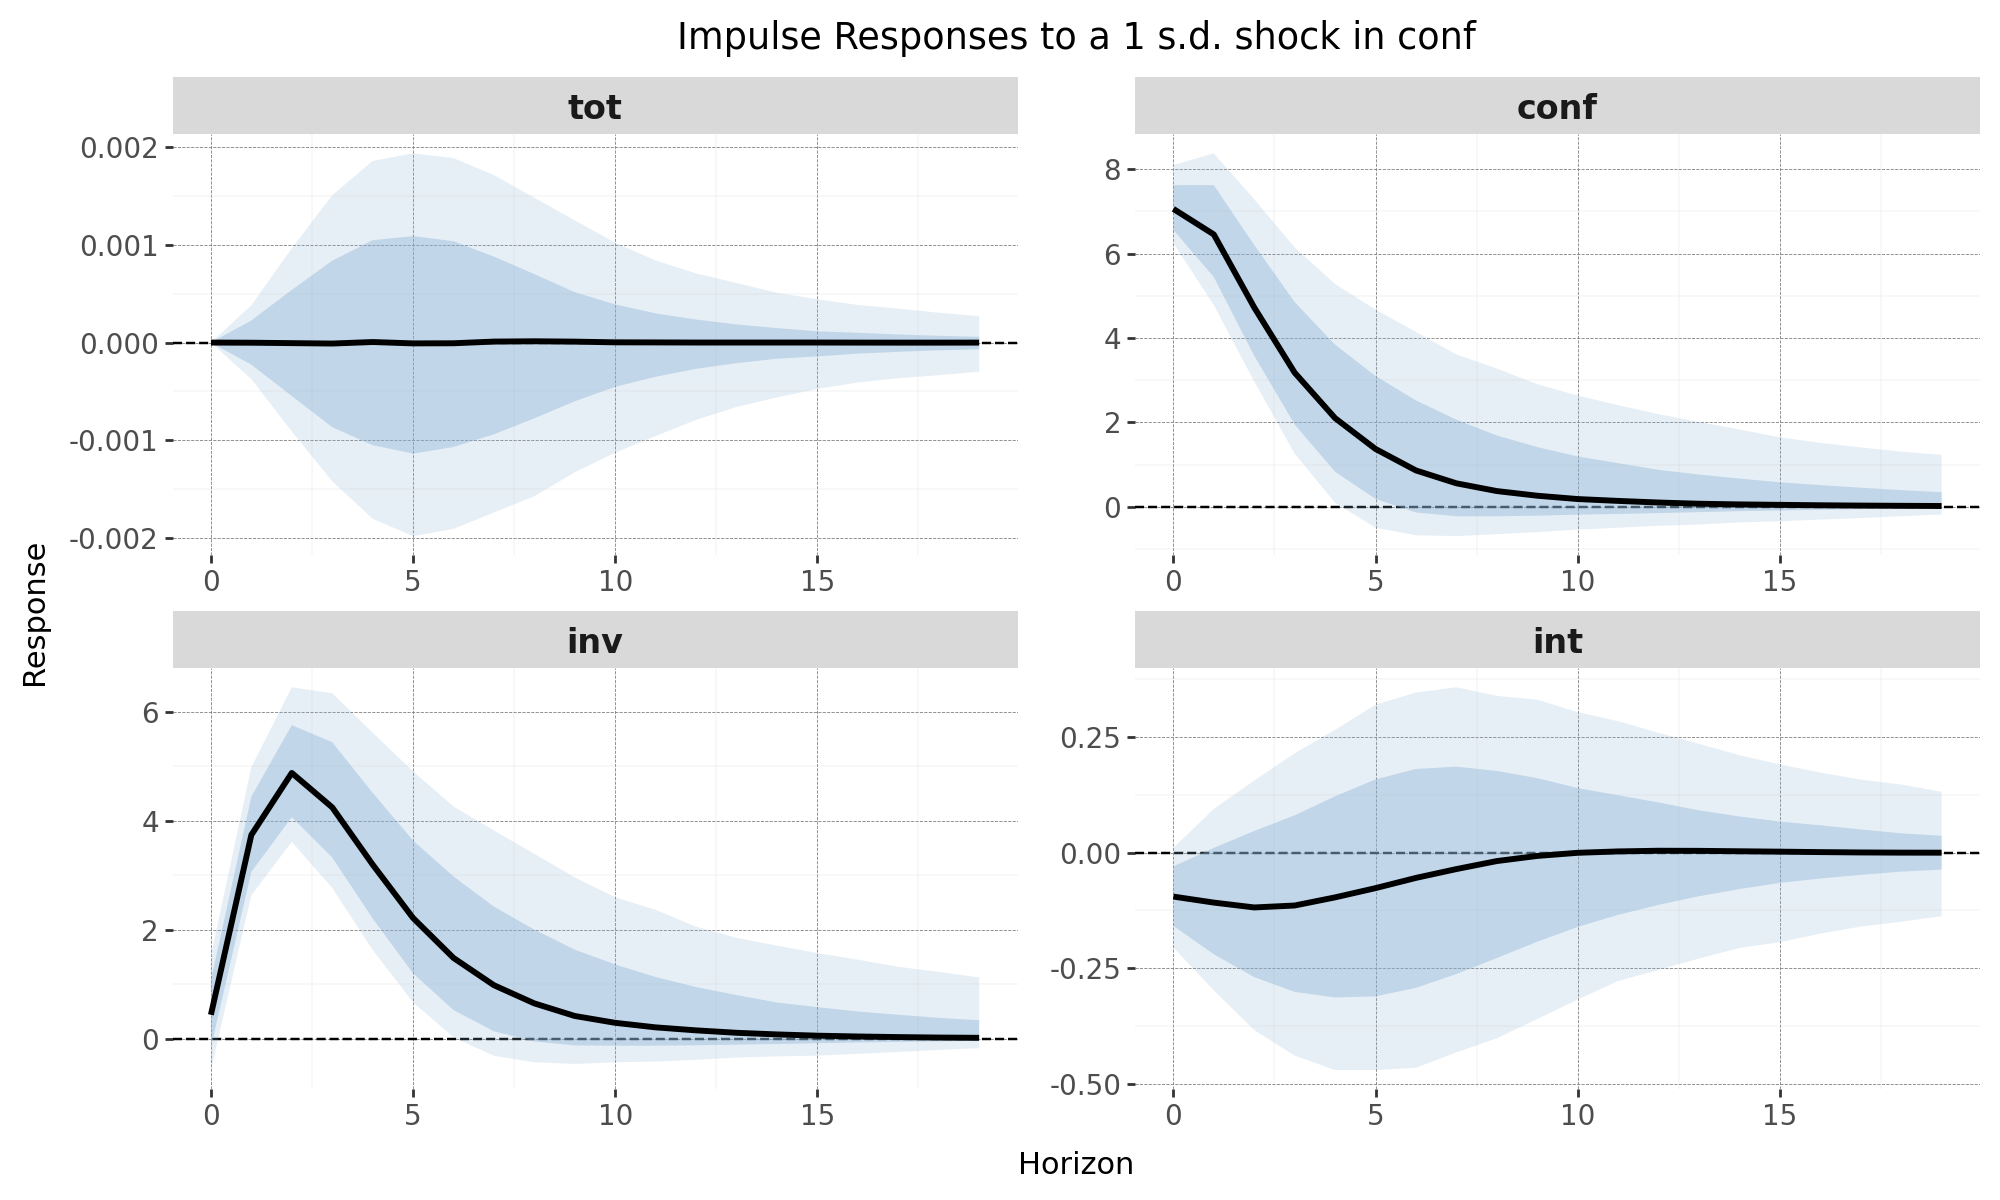

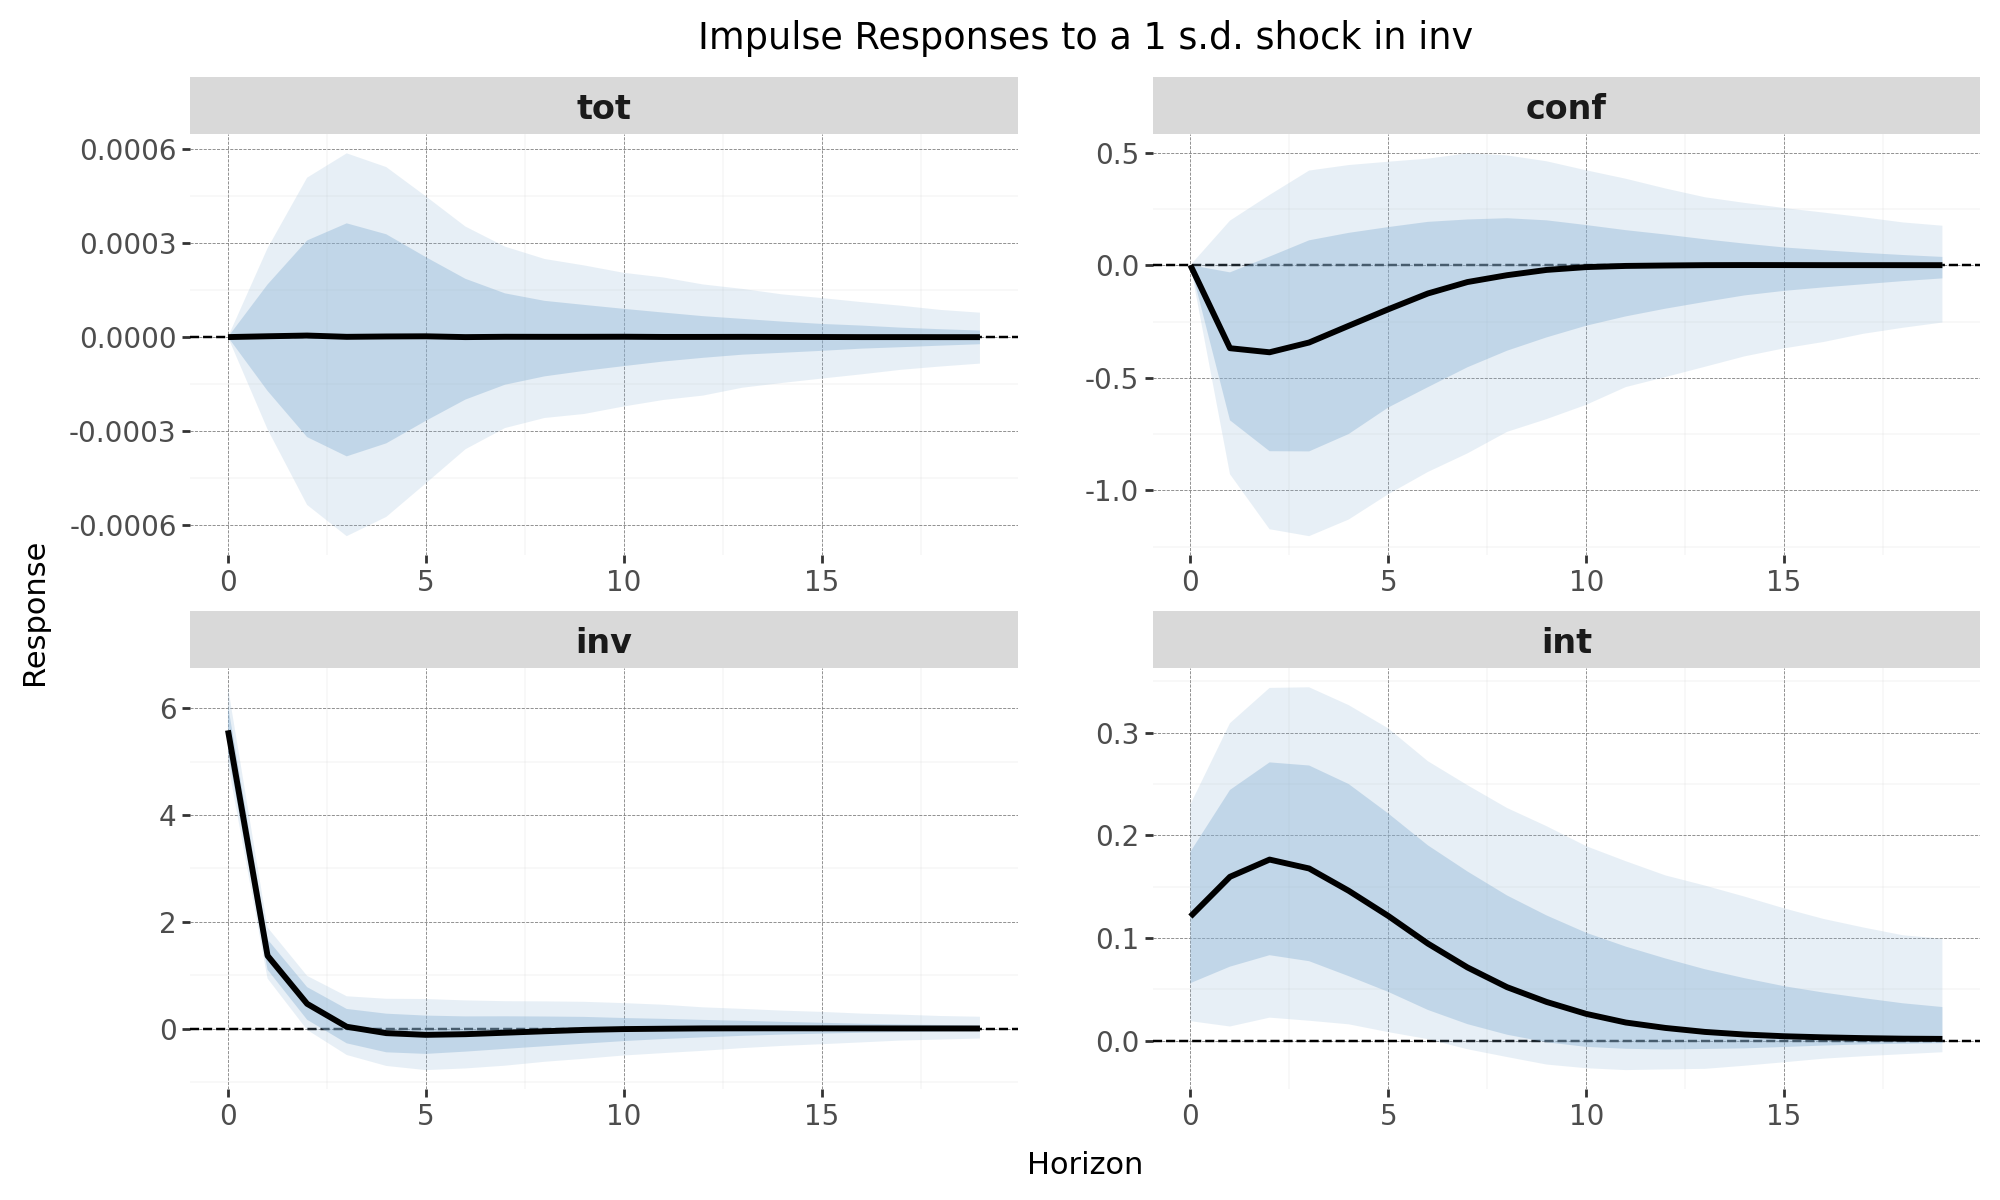

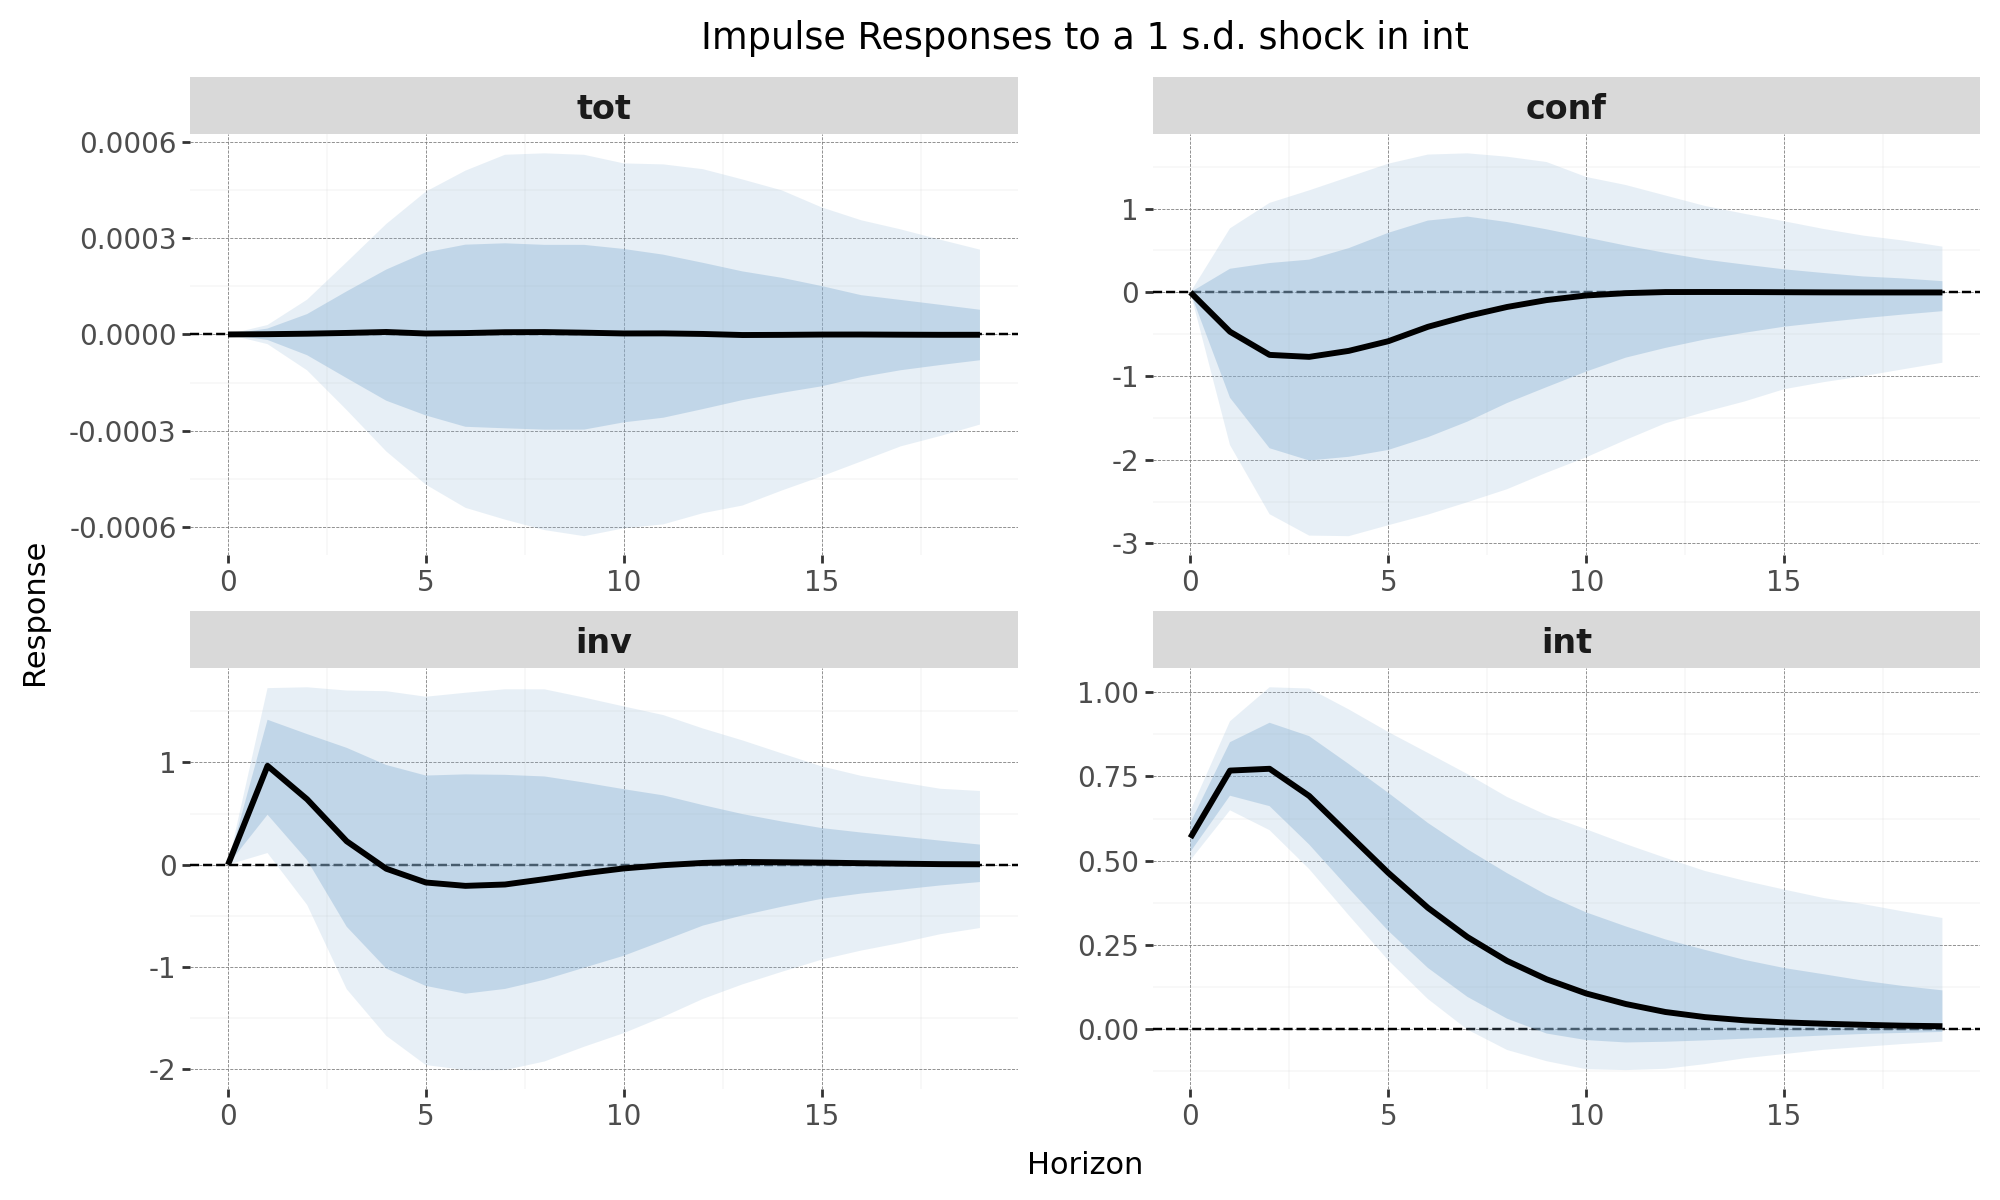

In [12]:
irfs_pd = bvar_pd.compute_irfs(plot_irfs=True, cred_interval=[0.68, 0.90])

## 5. Comparison: investment response to ToT and confidence shocks

The point of controlling for the pandemic is to recover *normal-time* shock propagation. We focus on the responses that motivated this exercise: how does **private investment** react to a one-standard-deviation shock to (i) **terms of trade** and (ii) **business confidence**?

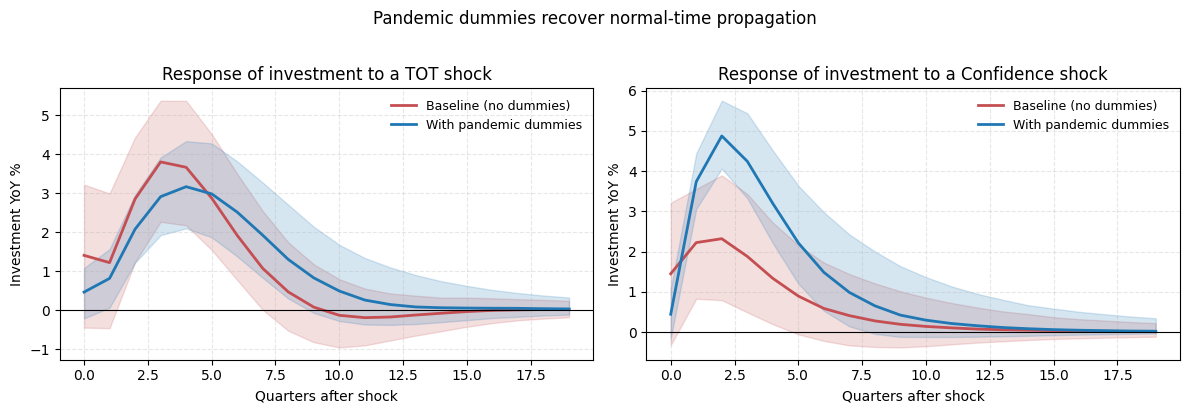

In [13]:
import matplotlib.pyplot as plt

inv_idx = list(df.columns).index('inv')
shock_indices = {'TOT shock': 0, 'Confidence shock': 1}
horizon = irfs_base.shape[1]
x = np.arange(horizon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (shock_name, shock_idx) in zip(axes, shock_indices.items()):
    for label, draws, color in [('Baseline (no dummies)', irfs_base, '#c44e52'),
                                 ('With pandemic dummies', irfs_pd, '#1f77b4')]:
        irf_path = draws[:, :, inv_idx, shock_idx]
        med = np.median(irf_path, axis=0)
        lo = np.percentile(irf_path, 16, axis=0)
        hi = np.percentile(irf_path, 84, axis=0)
        ax.plot(x, med, label=label, color=color, lw=2)
        ax.fill_between(x, lo, hi, color=color, alpha=0.18)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Response of investment to a {shock_name}')
    ax.set_xlabel('Quarters after shock')
    ax.set_ylabel('Investment YoY %')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('Pandemic dummies recover normal-time propagation', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Comparing reduced-form residuals

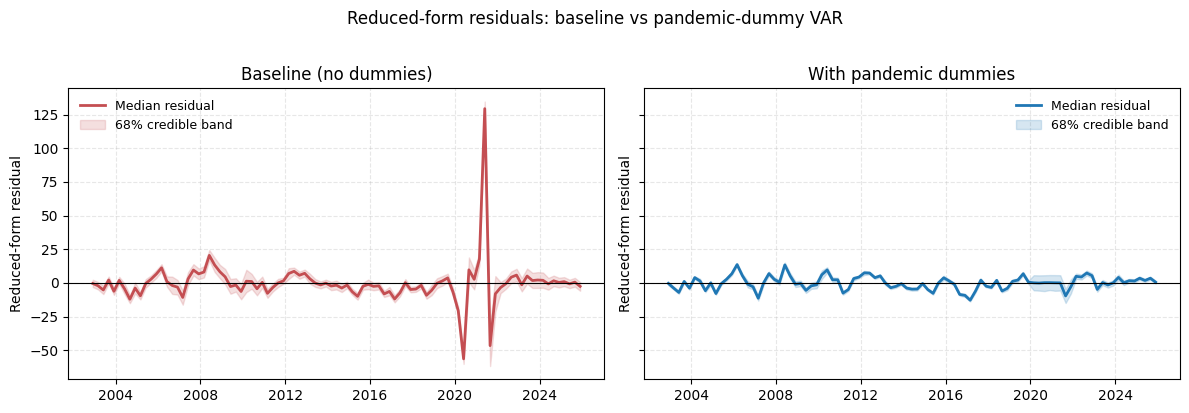

In [14]:
import numpy as np
import matplotlib.pyplot as plt

inv_idx = list(df.columns).index('inv')

# Residual paths: draws x time
resid_base = post_base["resid_draws"]
resid_pd   = post_pd["resid_draws"]
res_base_inv = resid_base[:, :, inv_idx]
res_pd_inv   = resid_pd[:, :, inv_idx]

# Use effective VAR sample dates
dates = df.index[-res_base_inv.shape[1]:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, label, draws, color in [
    (axes[0], 'Baseline (no dummies)', res_base_inv, '#c44e52'),
    (axes[1], 'With pandemic dummies', res_pd_inv, '#1f77b4')
]:
    med = np.median(draws, axis=0)
    lo = np.percentile(draws, 16, axis=0)
    hi = np.percentile(draws, 84, axis=0)
    ax.plot(dates, med, label='Median residual', color=color, lw=2)
    ax.fill_between(dates, lo, hi, color=color, alpha=0.18, label='68% credible band')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(label)
    ax.set_ylabel('Reduced-form residual')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('Reduced-form residuals: baseline vs pandemic-dummy VAR', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()